# Task 08 — Model Evaluation & Cross-Validation Strategies
Bulletproof evaluation for a heart-disease classifier: K-Fold vs. Stratified K-Fold vs. Leave-One-Out, learning/validation curves, and a paired statistical test between models — built to avoid the accuracy overestimation that caused a prior model to fail in production.

In [1]:
import sys
sys.path.append('src')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from data_loader import load_heart_disease
from preprocessing import clean, make_xy, FEATURES, TARGET
from modeling import (compare_cv_strategies, get_learning_curve, get_validation_curve,
                       paired_ttest_models, baseline_scores, make_pipeline, RANDOM_SEED)

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)

## 1. Load & Clean Data

In [2]:
raw = load_heart_disease("data/heart.csv")
df = clean(raw)
X, y = make_xy(df)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,33,0,2,94,511,1,0,191,0,4.9,1,1,2,1
1,66,1,3,98,335,0,1,159,1,5.2,0,2,3,1
2,61,0,2,117,558,0,1,93,1,1.8,1,0,2,1
3,50,1,0,188,460,0,0,88,1,1.9,0,2,0,1
4,50,1,3,143,411,1,0,185,0,5.4,0,3,3,1


In [3]:
print("Shape:", df.shape)
print("Target balance:\n", y.value_counts(normalize=True).round(3))

Shape: (300, 14)
Target balance:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

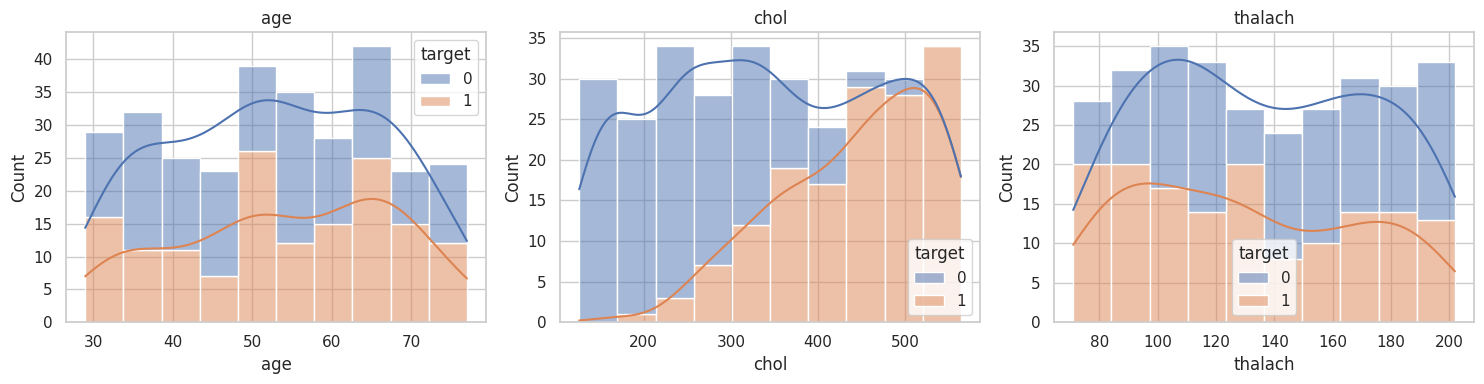

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "chol", "thalach"]):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax, multiple="stack")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/01_feature_distributions.png", dpi=150)
plt.show()

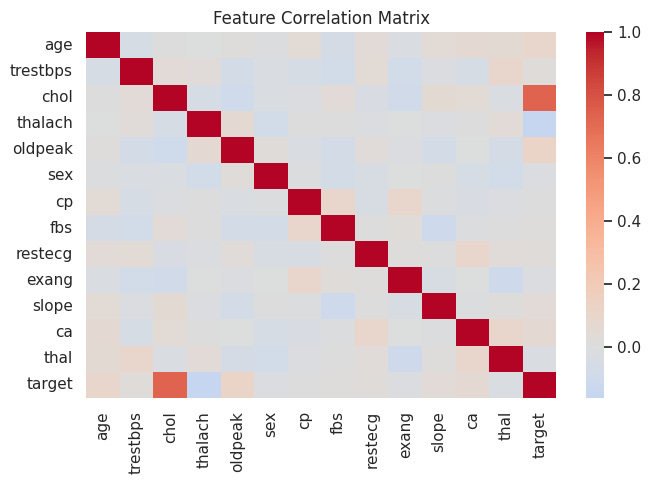

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/02_correlation_heatmap.png", dpi=150)
plt.show()

## 3. Preprocessing & Leakage Prevention
Scaling is fit **inside each CV fold** (via a `Pipeline`), not on the full dataset up front. Fitting a scaler on all data before splitting would leak test-fold mean/variance into training — a common, subtle source of over-optimistic accuracy, and part of what likely caused the prior model's 8% overestimation.

## 4. Cross-Validation Strategy Comparison
K-Fold, Stratified K-Fold, and Leave-One-Out on the same model, so we can see how much the evaluation *strategy itself* moves the reported score.

In [6]:
cv_comparison = compare_cv_strategies(X, y)
cv_comparison

,strategy,mean_accuracy,std_accuracy,n_folds
0,K-Fold (k=5),0.843333,0.044222,5
1,Stratified K-Fold (k=5),0.866667,0.018257,5
2,Leave-One-Out,0.846667,0.360309,300


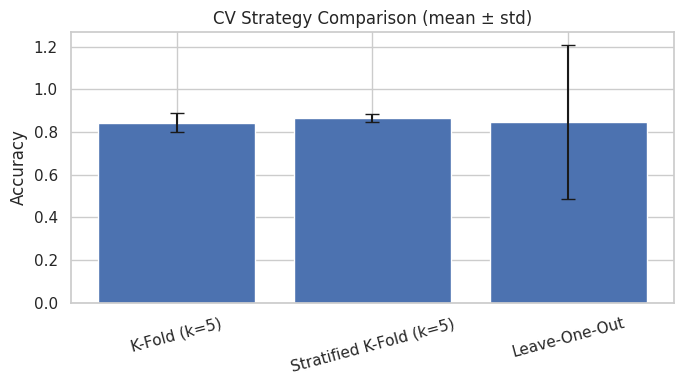

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cv_comparison["strategy"], cv_comparison["mean_accuracy"],
       yerr=cv_comparison["std_accuracy"], capsize=5)
ax.set_ylabel("Accuracy"); ax.set_title("CV Strategy Comparison (mean \u00b1 std)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/03_cv_strategy_comparison.png", dpi=150)
plt.show()

**Why Stratified K-Fold is the recommended default here:** plain K-Fold can produce folds with a different disease-prevalence mix than the full dataset (especially with 5 folds on a few hundred rows), inflating variance across folds. Stratified K-Fold keeps the target ratio constant per fold. Leave-One-Out is nearly unbiased but far higher-variance and computationally expensive at scale — noted as a reference point, not the production choice.

## 5. Learning Curve — Bias-Variance Diagnostic

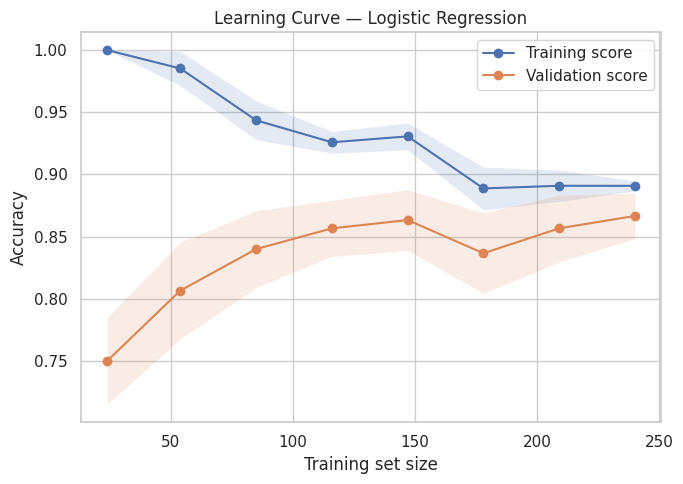

In [8]:
train_sizes, train_scores, val_scores = get_learning_curve(X, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training score")
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation score")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
ax.set_xlabel("Training set size"); ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Logistic Regression"); ax.legend()
plt.tight_layout()
plt.savefig("figures/04_learning_curve.png", dpi=150)
plt.show()

A persistent gap between training and validation score signals variance (overfitting); both curves converging to a low score signals bias (underfitting). Read the gap here to judge which regime the model is in before trusting its held-out accuracy.

## 6. Validation Curve — Regularization Strength

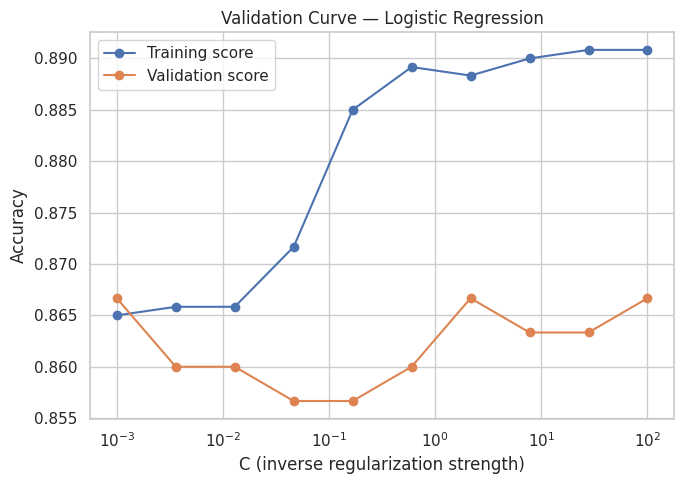

In [9]:
param_range, vc_train, vc_val = get_validation_curve(X, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(param_range, vc_train.mean(axis=1), 'o-', label="Training score")
ax.semilogx(param_range, vc_val.mean(axis=1), 'o-', label="Validation score")
ax.set_xlabel("C (inverse regularization strength)"); ax.set_ylabel("Accuracy")
ax.set_title("Validation Curve — Logistic Regression"); ax.legend()
plt.tight_layout()
plt.savefig("figures/05_validation_curve.png", dpi=150)
plt.show()

## 7. Statistical Comparison of Models
A single mean-accuracy number is not enough to say one model beats another — this runs a **paired t-test on matched per-fold scores** (Logistic Regression vs. Random Forest) to check whether any difference is statistically significant, not just noise.

In [10]:
ttest_result = paired_ttest_models(
    X, y,
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED),
)
ttest_result

{'mean_a': np.float64(0.8500000000000002),
 'mean_b': np.float64(0.85),
 't_stat': np.float64(7.899375304297575e-16),
 'p_value': np.float64(0.9999999999999993),
 'significant_at_0.05': np.False_}

## 8. Baseline Comparison

In [11]:
baseline = baseline_scores(X, y)
best_cv = cv_comparison.loc[cv_comparison["strategy"] == "Stratified K-Fold (k=5)", "mean_accuracy"].iloc[0]
print("Majority-class baseline accuracy:", round(baseline["mean_accuracy"], 3))
print("Logistic Regression (Stratified K-Fold):", round(best_cv, 3))

Majority-class baseline accuracy: 0.5
Logistic Regression (Stratified K-Fold): 0.867


## 9. Final Model Diagnostics — ROC & Confusion Matrix
Predictions here come from `cross_val_predict` under Stratified K-Fold, so every prediction is out-of-fold (never predicted by a model that saw that row in training).

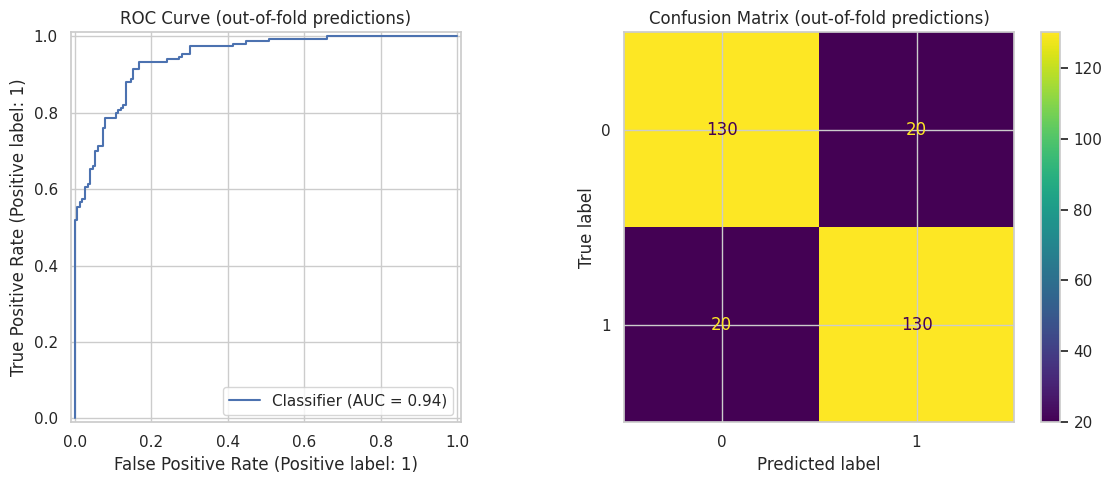

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
pipe = make_pipeline()
y_pred = cross_val_predict(pipe, X, y, cv=cv, method="predict")
y_proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y, y_proba, ax=axes[0])
axes[0].set_title("ROC Curve (out-of-fold predictions)")
ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[1])
axes[1].set_title("Confusion Matrix (out-of-fold predictions)")
plt.tight_layout()
plt.savefig("figures/06_roc_and_confusion_matrix.png", dpi=150)
plt.show()

## 10. Limitations
- Placeholder/synthetic data was used to build and test this pipeline; see README for swapping in the real UCI/Kaggle CSV.
- ~300 rows is small for a hospital-scale deployment; confidence intervals on accuracy stay fairly wide.
- Leave-One-Out is reported for comparison only — too slow to use as the default strategy at larger scale.
- The paired t-test assumes fold scores are roughly independent and normal; with only 10 folds this is an approximation, not a guarantee.
- Only Logistic Regression and Random Forest were compared; other model families (SVM, gradient boosting) were out of scope for this task.